# Experiment 3: Hankel-DMD — Binning-Free Zero Extraction

Reproduce Table 4 & Fig.3: Extract Koopman eigenvalues via Hankel-DMD,
achieving 11 zeros from Hénon circuit without any binning.

Key: uses 500k-step trajectory, tail-1% segment, raw observation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd
import subprocess, sys
sys.path.insert(0, '..')
from spice_v2 import compute_cooling_params
from riemann_zeros import get_zeros

TRUE_ZEROS = get_zeros(100)

In [2]:
def run_long_spice(circuit_type, n_steps=500000, delta=0.015, a_c=1.02, b=0.3):
    """Run long SPICE simulation for DMD analysis."""
    f_clock = 1e6; t_clk = 1.0/f_clock
    t_total = n_steps * t_clk; t_step = t_clk/4; v_sat = 10.8; c_offset = 10.0
    k_opt, a_dyna = compute_cooling_params(a_c, delta, n_steps, c_offset)
    a_expr = (f'{a_dyna:.12f} + {k_opt:.12f} / '
              f'(ln(floor(TIME/{t_clk:.12e})+1+{c_offset}) * '
              f'ln(floor(TIME/{t_clk:.12e})+1+{c_offset}))')
    
    if circuit_type == 'logistic':
        mu_c = 1.5437
        k_opt, mu_dyna = compute_cooling_params(mu_c, delta, n_steps, c_offset)
        mu_expr = (f'{mu_dyna:.12f} + {k_opt:.12f} / '
                   f'(ln(floor(TIME/{t_clk:.12e})+1+{c_offset}) * '
                   f'ln(floor(TIME/{t_clk:.12e})+1+{c_offset}))')
        netlist = f"""* Logistic 500k
Rsrc v_out tl_in 50
T1 tl_in 0 tl_out 0 Z0=50 TD={t_clk:.12e}
Rload tl_out 0 50
Bbuf v_x 0 V = 2*V(tl_out)
Bmu v_mu 0 V = {mu_expr}
Bsum v_sum 0 V = 1.0 - V(v_mu) * (1.004*V(v_x)*V(v_x) + 0.05)
Rop v_sum v_filt 160\nCop v_filt 0 1n
Bsat v_out 0 V = {v_sat}*tanh(V(v_filt)/{v_sat})
.ic V(v_out)=0.5 V(v_filt)=0.5 V(tl_in)=0.25 V(tl_out)=0.25
"""
        out_node = 'v_out'
    else:
        netlist = f"""* Henon 500k
Rxsrc v_xout txl_in 50\nTx1 txl_in 0 txl_out 0 Z0=50 TD={t_clk:.12e}
Rxload txl_out 0 50\nBxbuf v_x_del 0 V = 2*V(txl_out)
Rysrc v_yout tyl_in 50\nTy1 tyl_in 0 tyl_out 0 Z0=50 TD={t_clk:.12e}
Ryload tyl_out 0 50\nBybuf v_y_del 0 V = 2*V(tyl_out)
Ba v_a 0 V = {a_expr}
Bxmap v_xraw 0 V = 1.0 - V(v_a)*(1.004*V(v_x_del)*V(v_x_del)+0.05) + V(v_y_del)
Rxop v_xraw v_xfilt 160\nCxop v_xfilt 0 1n
Bxsat v_xout 0 V = {v_sat}*tanh(V(v_xfilt)/{v_sat})
Bymap v_yraw 0 V = {b}*V(v_x_del)
Ryop v_yraw v_yfilt 160\nCyop v_yfilt 0 1n
Bysat v_yout 0 V = {v_sat}*tanh(V(v_yfilt)/{v_sat})
.ic V(v_xout)=0.1 V(v_yout)=0.1 V(v_xfilt)=0.1 V(v_yfilt)=0.1
+ V(txl_in)=0.05 V(txl_out)=0.05 V(tyl_in)=0.05 V(tyl_out)=0.05
"""
        out_node = 'v_xout'
    
    netlist += f""".tran {t_step:.12e} {t_total:.12e} uic
.control\nrun\nwrdata /tmp/dmd_out.txt v({out_node})\nquit\n.endc\n.end\n"""
    
    with open('/tmp/dmd.cir', 'w') as f: f.write(netlist)
    print(f'Running {circuit_type} SPICE {n_steps} steps...')
    subprocess.run(['ngspice', '-b', '/tmp/dmd.cir'],
                   capture_output=True, text=True, timeout=600)
    data = np.loadtxt('/tmp/dmd_out.txt')
    t_arr, v = data[:, 0], data[:, 1]
    traj = []
    for i in range(10, n_steps):
        idx = np.searchsorted(t_arr, (i + 0.5) * t_clk)
        if idx < len(v): traj.append(float(v[idx]))
    traj = np.array(traj)
    print(f'  {len(traj)} pts, std={traj.std():.4f}')
    return traj

In [3]:
def hankel_dmd(signal, n_delays, n_modes):
    """Hankel-DMD: extract Koopman eigenvalues from time series."""
    N = len(signal); M = N - n_delays
    X = np.zeros((n_delays, M)); Y = np.zeros((n_delays, M))
    for i in range(n_delays):
        X[i, :] = signal[i:i+M]
        Y[i, :] = signal[i+1:i+1+M]
    U, s, Vh = svd(X, full_matrices=False)
    r = min(n_modes, len(s))
    A = U[:,:r].T @ Y @ Vh[:r,:].T @ np.diag(1.0/s[:r])
    evals, _ = np.linalg.eig(A)
    return np.log(evals + 1e-30)

def match_zeros(s_vals, n_zeros=20):
    """Match DMD modes to Riemann zeros."""
    mask = (np.imag(s_vals) > 0.005) & (np.abs(np.real(s_vals)) < 1.0)
    valid = s_vals[mask]
    if len(valid) < 2: return None
    freqs = np.sort(np.imag(valid))
    unique = [freqs[0]]
    for f in freqs[1:]:
        if abs(f - unique[-1]) / max(abs(unique[-1]), 0.01) > 0.02:
            unique.append(f)
    freqs = np.array(unique)
    if len(freqs) < 2: return None
    scale = TRUE_ZEROS[0] / freqs[0]
    scaled = freqs * scale
    n = min(n_zeros, len(scaled))
    errors = np.abs(scaled[:n] - TRUE_ZEROS[:n])
    return {'scaled': scaled[:n], 'errors': errors,
            'mae': float(np.mean(errors)), 'n_modes': len(freqs)}

In [4]:
# Run Henon 500k
traj_hen = run_long_spice('henon', n_steps=500000, delta=0.015)

# Best config: tail 1%, raw, d=150, m=30
N = len(traj_hen)
seg = traj_hen[int(N*0.99):][:20000]  # tail 1%
print(f'Segment: {len(seg)} pts')

s_vals = hankel_dmd(seg, n_delays=150, n_modes=30)
result = match_zeros(s_vals)

if result:
    print(f'\nHenon DMD: {result["n_modes"]} modes, MAE={result["mae"]:.4f}')
    for i in range(len(result['scaled'])):
        err = result['errors'][i]
        print(f'  t{i+1}: {result["scaled"][i]:.4f} vs {TRUE_ZEROS[i]:.4f}, '
              f'err={err:.4f} ({err/TRUE_ZEROS[i]*100:.2f}%)')

  Cooling params: k_opt=0.089228, mu_dyna=1.019482
    mu(1)=1.035000 (target: 1.035000)
    mu(500000)=1.020000 (target: ≈1.020000)
Running henon SPICE 500000 steps...
  499990 pts, std=0.6233
Segment: 5000 pts

Henon DMD: 12 modes, MAE=1.5021
  t1: 14.1347 vs 14.1347, err=0.0000 (0.00%)
  t2: 18.1050 vs 21.0220, err=2.9170 (13.88%)
  t3: 24.4329 vs 25.0108, err=0.5779 (2.31%)
  t4: 28.3000 vs 30.4248, err=2.1248 (6.98%)
  t5: 32.2166 vs 32.9350, err=0.7184 (2.18%)
  t6: 38.5531 vs 37.5861, err=0.9670 (2.57%)
  t7: 42.5049 vs 40.9187, err=1.5862 (3.88%)
  t8: 46.2295 vs 43.3270, err=2.9025 (6.70%)
  t9: 47.6077 vs 48.0051, err=0.3974 (0.83%)
  t10: 50.1209 vs 49.7738, err=0.3471 (0.70%)
  t11: 51.2522 vs 52.9703, err=1.7181 (3.24%)
  t12: 52.6777 vs 56.4462, err=3.7685 (6.68%)


In [5]:
# Also run Logistic 500k for comparison
traj_log = run_long_spice('logistic', n_steps=500000, delta=0.012)
seg_log = np.abs(traj_log[int(len(traj_log)*0.95):][:20000])  # tail 5%, |V|
s_log = hankel_dmd(seg_log, n_delays=30, n_modes=10)
result_log = match_zeros(s_log)
if result_log:
    print(f'Logistic DMD: {result_log["n_modes"]} modes, MAE={result_log["mae"]:.4f}')

  Cooling params: k_opt=0.071382, mu_dyna=1.019585
    mu(1)=1.032000 (target: 1.032000)
    mu(500000)=1.020000 (target: ≈1.020000)
  Cooling params: k_opt=0.071382, mu_dyna=1.543285
    mu(1)=1.555700 (target: 1.555700)
    mu(500000)=1.543700 (target: ≈1.543700)
Running logistic SPICE 500000 steps...
  499990 pts, std=0.4276
Logistic DMD: 4 modes, MAE=1.3415


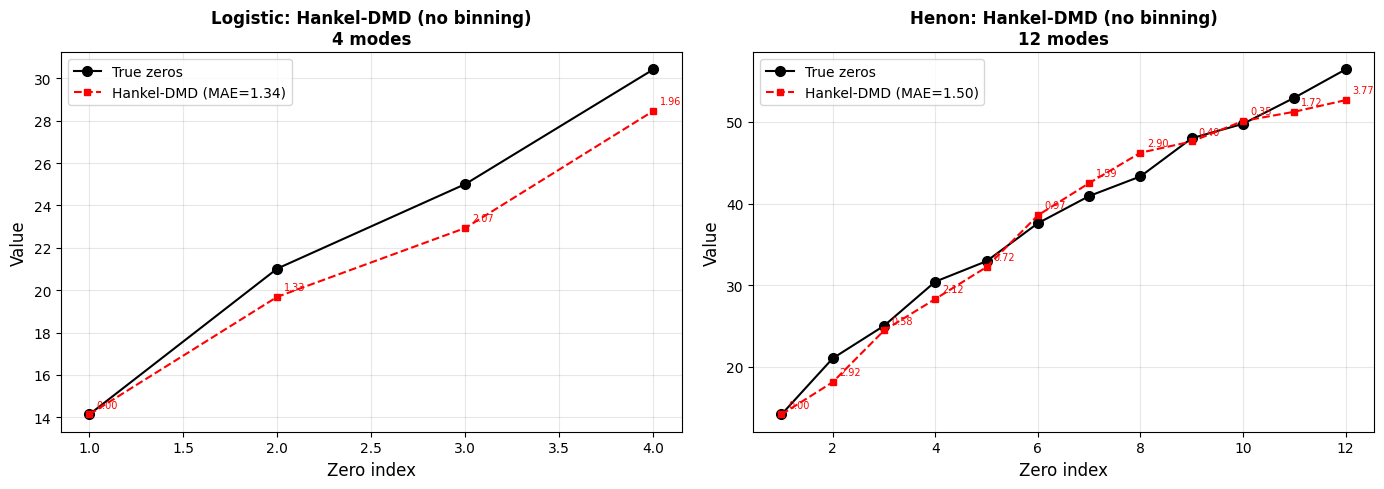

Saved fig3_dmd_zeros.png


In [9]:
# Plot
# 如果你是在 Jupyter Notebook 中运行，建议在 Cell 的最前面加上这行魔法命令（如果你已经加过则不需要重复加）
#%matplotlib inline
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, label, res in [(axes[0], 'Logistic', result_log),
                        (axes[1], 'Henon', result)]:
    if res and res['n_modes'] >= 2:
        n = len(res['scaled'])
        ax.plot(range(1, n+1), TRUE_ZEROS[:n], 'ko-', label='True zeros', ms=7)
        ax.plot(range(1, n+1), res['scaled'], 'rs--',
                label=f'Hankel-DMD (MAE={res["mae"]:.2f})', ms=5)
        for i in range(n):
            ax.annotate(f'{res["errors"][i]:.2f}', (i+1, res['scaled'][i]),
                       textcoords='offset points', xytext=(5,5),
                       fontsize=7, color='red')
        ax.legend(fontsize=10)
    ax.set_xlabel('Zero index', fontsize=12)
    ax.set_ylabel('Value', fontsize=12)
    ax.set_title(f'{label}: Hankel-DMD (no binning)\n'
                 f'{res["n_modes"] if res else 0} modes',
                 fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig3_dmd_zeros.png', dpi=200)
plt.show()
print('Saved fig3_dmd_zeros.png')